# K-Means Clustering Implementation.

In [5]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=23)
X_train, X_test, _, _ = train_test_split(X,_, test_size=0.2, random_state=42)

In [2]:
X.shape

(1000, 2)

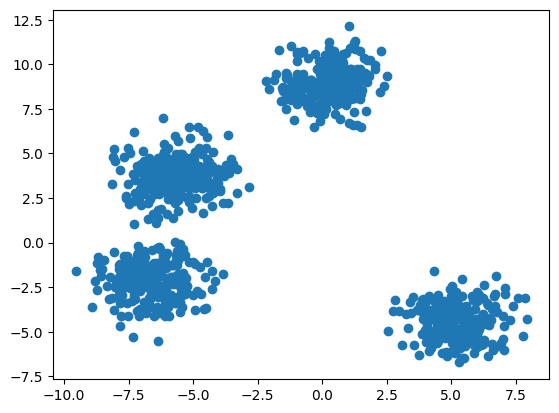

In [11]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1])

In [6]:
### Elbow method Manual
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

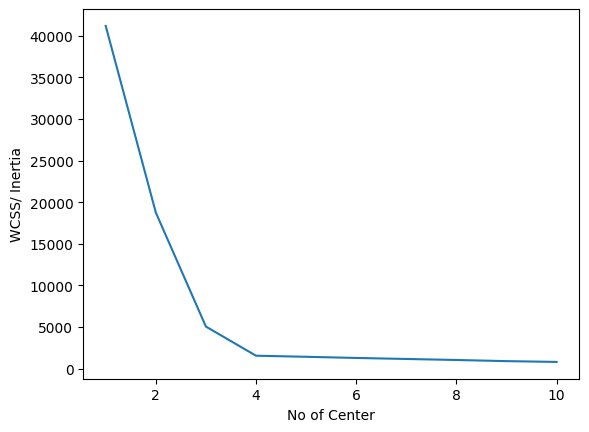

In [10]:
plt.plot(range(1,11),wcss)
plt.xlabel("No of Center")
plt.ylabel("WCSS/ Inertia")
plt.show()

In [25]:
# ### Elbow method using KneeLocator
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss, curve="convex",direction="decreasing")
kl.elbow

np.int64(3)

In [12]:
kmeans = KMeans(n_clusters=4, init="k-means++")
y_labels = kmeans.fit_predict(X_train)
y_test_labels = kmeans.predict(X_test)

Text(0.5, 1.0, 'TRAIN')

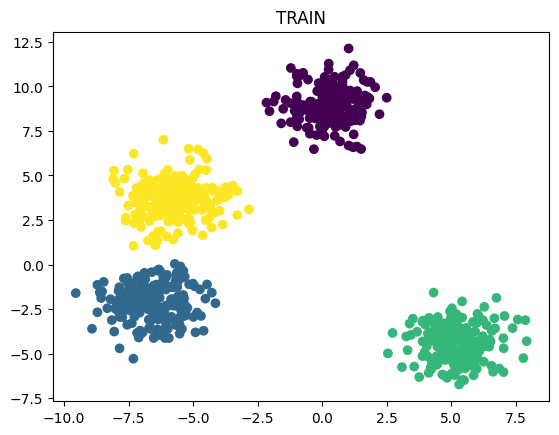

In [15]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)
plt.title("TRAIN")

Text(0.5, 1.0, 'TEST')

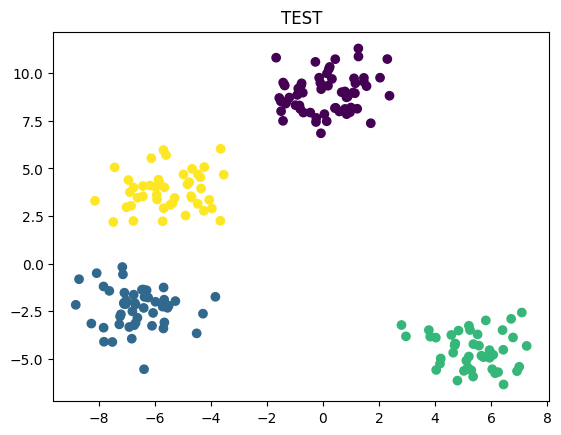

In [14]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_labels)
plt.title("TEST")

In [23]:
### Performance matrix
### Silhouette score
from sklearn.metrics import silhouette_score
sil_coeff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init= "k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    sil_coeff.append(score)

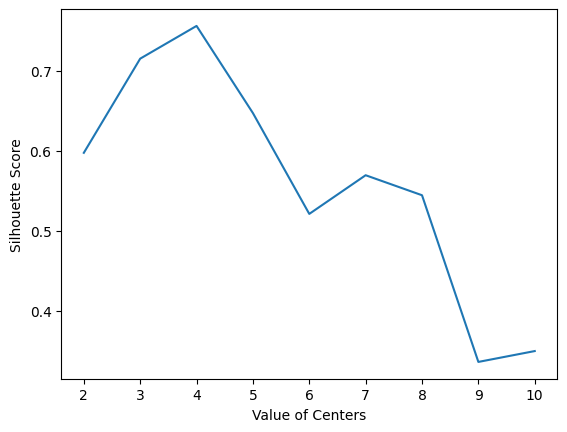

In [24]:
plt.plot(range(2,11),sil_coeff)
plt.xlabel("Value of Centers")
plt.ylabel("Silhouette Score")
plt.show()